#Sviluppo di un Filtro Anti-Hater per Social Network: Un Approccio basato su LSTM e Word Embeddings GloVe
##Sitografia

- [Basics of Using Pre-trained GloVe Vectors in Python](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)

- [GloVe: Global Vectors for Word Representation](https://nlp.stanford.edu/projects/glove/)

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.backend import clear_session
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import os
import re

In [ ]:
URL_Layer = "https://nlp.stanford.edu/data/glove.6B.zip"
!wget $URL_Layer
!unzip glove.6B.zip

--2025-10-30 09:49:37--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-10-30 09:49:37--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  4.98MB/s    in 2m 39s  

2025-10-30 09:52:16 (5.18 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflatin

Parametri di configurazione e caricamento dei dati.

In [ ]:
MAX_WORDS = 20000  #Numero massimo di parole uniche da considerare nel vocabolario
EMBEDDING_DIM = 100 #Dimensione dei vettori GloVe
LSTM_UNITS = 128    #Numero di unità nella LSTM bidirezionale
DROPOUT_RATE = 0.4 #Tasso di Dropout per regolarizzazione
BATCH_SIZE = 128
EPOCHS = 10
THRESHOLD = 0.4   #Soglia per convertire le probabilità in output binari (per equilibrare meglio precision e recall)
LABEL_COLUMNS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
OUTPUT_UNITS = len(LABEL_COLUMNS)
URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/Filter_Toxic_Comments_dataset.csv"
MODEL_FILENAME = "toxic_comment_detector.keras"

In [ ]:
def load_data():
    """
    Carica il dataset dall'URL specificato.
    """
    return pd.read_csv(URL)

df = load_data()

Preprocessing del testo e Tokenizzazione.

In [ ]:
def clean_text(text: str) -> str:
    """
    Applica una serie di operazioni di preprocessing al testo.

    Args:
        text (str): Testo da preprocessare.

    Returns:
        str: Testo preprocessato.
    """
    text = str(text).lower() #Trasforma il testo in minuscolo
    text = re.sub(r'http\S+', '', text) #Rimuove URL
    text = re.sub(r'&[a-z]+;', '', text) #Rimuove HTML
    text = re.sub('\n', ' ', text) #Rimuove i ritorno a capo

    return text.strip()

df['comment_text'] = df['comment_text'].apply(clean_text)

In [ ]:
CONTRACTION_MAP = {
    "don't": "do not",
    "can't": "cannot",
    "won't": "will not",
    "it's": "it is",
    "i'm": "i am",
}

def expand_contractions(text: str, contraction_mapping: Dict[str, str]) -> str:
    """
    Sostituisce le contrazioni presenti nel testo con la loro forma estesa.

    Args:
        text (str): Testo contenente potenziali contrazioni.
        contraction_mapping (dict): Dizionario di mappatura contrazione -> espansione.

    Returns:
        str: Testo con le contrazioni espanse e gli apostrofi rimanenti rimossi.
    """

    for contraction, expansion in contraction_mapping.items():
        text = re.sub(re.escape(contraction), expansion, text)

    text = re.sub(r"'", '', text)
    return text

df['comment_text'] = df['comment_text'].apply(expand_contractions, contraction_mapping=CONTRACTION_MAP)


In [ ]:
X = df['comment_text'].values
y = df[LABEL_COLUMNS].values

In [ ]:
#Split Train/Validation/Test (80/10/10)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=np.max(y, axis=1))
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nDimensioni dei set: \nTrain: {len(X_train)} \nValidation: {len(X_val)} \nTest: {len(X_test)}")

#Tokenizzazione
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(list(X_train))

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = len(max(X_train_seq, key=len))
print(f"Lunghezza massima delle sequenze: {max_len}")

vocabulary_size = len(tokenizer.word_index)+1
print(f"Dimensioni del vocabolario: {vocabulary_size}")

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


Dimensioni dei set: 
Train: 127656 
Validation: 15957 
Test: 15958
Lunghezza massima delle sequenze: 1400
Dimensioni del vocabolario: 167089


Andiamo a creare una matrice di pesi sfruttando il file "glove.6B.100d.txt" per costruire un modello RNN con layer di embedding pre-addestrato.

In [ ]:
#Trasfer Learning: Integrazione Embedding Glove

def get_glove_embedding_matrix(word_index: Dict[str, int], embedding_dim: int, vocab_size: int) -> np.ndarray:
    """
    Carica i vettori di embedding GloVe da un file e crea la matrice di embedding
    per l'utilizzo nel layer di Embedding. Gestisce le parole non trovate
    assegnando un vettore di zeri.

    Args:
        word_index (dict): Mappatura parola -> indice generata dal tokenizer Keras.
        embedding_dim (int): Dimensione dei vettori di embedding (es. 100 per GloVe.6B.100d).
        vocab_size (int): Dimensione massima del vocabolario.

    Returns:
        np.ndarray or None: La matrice di embedding (vocab_size, embedding_dim)
        o None se il file GloVe non viene trovato.
    """
    print("\nCaricamento embeddings GloVe e creazione matrice")

    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    embeddings_dict = {}

    try:
        with open("glove.6B.100d.txt", 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                if len(values) > 1 and len(values[1:]) == embedding_dim:
                    vector = np.asarray(values[1:], "float32")
                    embeddings_dict[word] = vector

        found_count = 0

        for word, i in word_index.items():
            if i < MAX_WORDS:
                embedding_vector = embeddings_dict.get(word)

                if embedding_vector is not None:
                    embedding_matrix[i] = embedding_vector
                    found_count += 1
                else:
                    #Per le parole non trovate, la riga resta a np.zeros
                    pass

    except FileNotFoundError:
        print("\nERRORE: File GloVe non trovato. La matrice è interamente di zeri. ")
        return None

    print(f"Matrice di embedding creata. Trovate {found_count} parole in GloVe su {min(len(word_index), MAX_WORDS)} parole nel vocabolario.")
    return embedding_matrix

embedding_matrix = get_glove_embedding_matrix(tokenizer.word_index, EMBEDDING_DIM, vocab_size=vocabulary_size)


Caricamento embeddings GloVe e creazione matrice
Matrice di embedding creata. Trovate 18888 parole in GloVe su 20000 parole nel vocabolario.


Funzioni per valutare il modello.

In [ ]:
def evaluate_model_multilabel(model: tf.keras.Model, X_data_padded: np.ndarray, y_true: np.ndarray, threshold: float=0.5) -> np.ndarray:
    """
    Calcola le metriche richieste (Accuracy, Precision, Recall, F1-Score)
    per la classificazione multi-label dopo aver binarizzato le probabilità di predizione.

    Args:
        model (tf.keras.Model): Il modello Keras addestrato.
        X_data_padded (np.ndarray): Dati di input (sequenze paddate) da valutare.
        y_true (np.ndarray): Le vere etichette binarie (Ground Truth).
        threshold (float, optional): Soglia per la binarizzazione delle probabilità, default a 0.5.

    Returns:
        np.ndarray: Vettore di predizioni binarie binarizzato (0 o 1).
    """
    print("\n" + "="*50)
    print("VALUTAZIONE MODELLO")
    print("="*50)

    y_pred_proba = model.predict(X_data_padded)

    # Binarizzazione
    y_pred_binary = (y_pred_proba > threshold).astype(int)

    print(f"\n--- Metriche di Valutazione (Soglia: {threshold}) ---")

    f1_globale = f1_score(y_true, y_pred_binary, average='micro')
    precision_globale = precision_score(y_true, y_pred_binary, average='micro')
    recall_globale = recall_score(y_true, y_pred_binary, average='micro')
    accuracy_globale = accuracy_score(y_true, y_pred_binary)

    #F1-Score per Categoria
    f1_per_label = f1_score(y_true, y_pred_binary, average=None)

    print(f"Accuratezza Globale (Intera riga corretta): {accuracy_globale:.4f}")
    print(f"Precision Micro (Globale): {precision_globale:.4f}")
    print(f"Recall Micro (Globale): {recall_globale:.4f}")
    print(f"F1-Score Micro (Globale): {f1_globale:.4f}")

    print("\nF1-Score per Categoria:")
    for i, label in enumerate(LABEL_COLUMNS):
        print(f" - {label:<15}: {f1_per_label[i]:.4f}")

    return y_pred_binary


#Esempio su un nuovo commento
def predict_new_comment(model: tf.keras.Model, tokenizer: tf.keras.preprocessing.text.Tokenizer, comment: str, threshold: float=0.5) ->None:
    """
    Esegue l'inferenza su un nuovo commento, applicando il
    preprocessing, la predizione e la binarizzazione per stampare i risultati.

    Args:
        model (tf.keras.Model): Il modello addestrato.
        tokenizer (tf.keras.preprocessing.text.Tokenizer): Il tokenizer addestrato.
        comment (str): Il commento di testo da analizzare.
        threshold (float, optional): Soglia per la binarizzazione delle probabilità, default a 0.5.
    """

    #Preprocessing del commento
    comment = clean_text(comment)
    comment = expand_contractions(comment, contraction_mapping=CONTRACTION_MAP)

    seq = tokenizer.texts_to_sequences([comment])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')

    #Predizione
    proba = model.predict(padded_seq)[0]

    #Binarizzazione
    prediction = (proba > threshold).astype(int)

    results = {LABEL_COLUMNS[i]: prediction[i] for i in range(OUTPUT_UNITS)}

    print("\n--- Analisi del Commento ---")
    print(f"Commento: '{comment}'")
    print("Predizioni (0=Assente, 1=Presente):")
    for label, status in results.items():
        print(f" - {label:<15}: {'TOSSICO' if status == 1 else 'Pulito'} ({proba[LABEL_COLUMNS.index(label)]:.2f})")

    if any(prediction == 1):
        print("\nRISULTATO: COMMENTO DANNOSO - FILTRARE!")
    else:
        print("\nRISULTATO: Commento accettabile.")




Funzione per la costruzione del modello.

In [ ]:
def create_model(embedding_matrix: np.ndarray) -> tf.keras.models.Sequential:
    """
    Definisce l'architettura Bi-LSTM per la classificazione multi-label,
    inizializzata con embedding GloVe.

    Args:
        embedding_matrix (np.ndarray): Matrice dei pesi di embedding (GloVe).

    Returns:
        tf.keras.models.Sequential: Il modello Keras già compilato.
    """

    clear_session()

    model = Sequential([
        Embedding(
            input_dim=vocabulary_size,
            output_dim=EMBEDDING_DIM,
            weights=[embedding_matrix],
            trainable=False,
            #mask_zero=True
        ),
        BatchNormalization(),
        Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        Dense(OUTPUT_UNITS, activation='sigmoid')
    ])

    model.compile(
        #optimizer = "rmsprop",
        optimizer = Adam(learning_rate=1e-3, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)]
    )

    print("\nModello LSTM-Glove creato e compilato.")

    model.build(input_shape=(None, max_len))
    model.summary()
    return model

Funzioni per salvare e caricare il modello.

In [ ]:
def save_model(model: tf.keras.Model = None) -> None:
    """
    Salva il modello in un file .keras per il riutilizzo.

    Args:
        model (tf.keras.Model): L'istanza del modello Keras da salvare, default a None.
    """
    if model is None:
        print("Errore, devi forninre un'istanza del modello da salvare!")
    else:
        try:
            model.save_model(MODEL_FILENAME)
        except Exception as e:
            print(f"Errore nel path del file: {e}")

def load_trained_model(model_filename: str) -> tf.keras.Model:
    """
    Carica un modello Keras addestrato da un file.

    Args:
        model_filename (str): Il percorso del file del modello da caricare.

    Returns:
        tf.keras.Model or None: Il modello Keras caricato o None in caso di errore.
    """

    if not os.path.exists(model_filename):
        print("Errore, il file non esiste!")
        return None
    else:
        try:
            model = load_model(model_filename)
            print(f"Modello caricato con successo da {model_filename}!")
            return model
        except Exception as e:
            print(f"Errore nel caricamento del file! {e}")
            return None

Funzione per plottare l'andamento dell'addestramento

In [ ]:
def plot_train(hist):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label="loss")
    plt.plot(hist.history['accuracy'], label="accuracy")
    plt.legend()
    plt.ylim((0,1.5))
    plt.title("Train")
    plt.subplot(1,2,2)
    plt.plot(hist.history['val_loss'], label="val_loss")
    plt.plot(hist.history['val_accuracy'], label="val_accuracy")
    plt.legend()
    plt.ylim((0,1.5))
    plt.title("Test");

Costruiamo il modello LSTM-Glove, con il layer di embedding pre-addestrato. **(Transfer Learning)**

In [ ]:
model_transfer_learning = create_model(embedding_matrix)


Modello LSTM-Glove creato e compilato.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1400, 100)      │    16,708,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1400, 100)      │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1400, 256)      │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1400, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1400, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,341,626 (66.15 MB)

 Trainable params: 631,502 (2.41 MB)

 Non-trainable params: 16,710,124 (63.74 MB)

Addestriamo il modello LSTM-Glove.

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True), #Ferma l'addestramento se la validation loss non migliora
    ModelCheckpoint('best_hater_filter_model.keras', monitor='val_loss', save_best_only=True) #Salva il modello migliore
]

print("\nInizio addestramento del modello...")

history = model_transfer_learning.fit(
    X_train_padded,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_padded, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\nAddestramento completato.")


Inizio addestramento del modello...
Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 472s 468ms/step - accuracy: 0.4554 - auc: 0.7604 - loss: 0.2980 - val_accuracy: 0.9609 - val_auc: 0.9458 - val_loss: 0.0552
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 467s 468ms/step - accuracy: 0.9562 - auc: 0.9535 - loss: 0.0564 - val_accuracy: 0.9937 - val_auc: 0.9371 - val_loss: 0.0546
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 468s 469ms/step - accuracy: 0.9708 - auc: 0.9574 - loss: 0.0539 - val_accuracy: 0.9892 - val_auc: 0.9577 - val_loss: 0.0522
Epoch 4/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 470s 470ms/step - accuracy: 0.9351 - auc: 0.9585 - loss: 0.0501 - val_accuracy: 0.9895 - val_auc: 0.9539 - val_loss: 0.0500
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 470s 471ms/step - accuracy: 0.9329 - auc: 0.9616 - loss: 0.0487 - val_accuracy: 0.9887 - val_auc: 0.9654 - val_loss: 0.0482
Epoch 6/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 472s 473ms/step - accuracy: 0.9347 - auc: 0.9673 - loss: 0.0483 - val_accuracy: 0.9855 - val_auc: 0.935

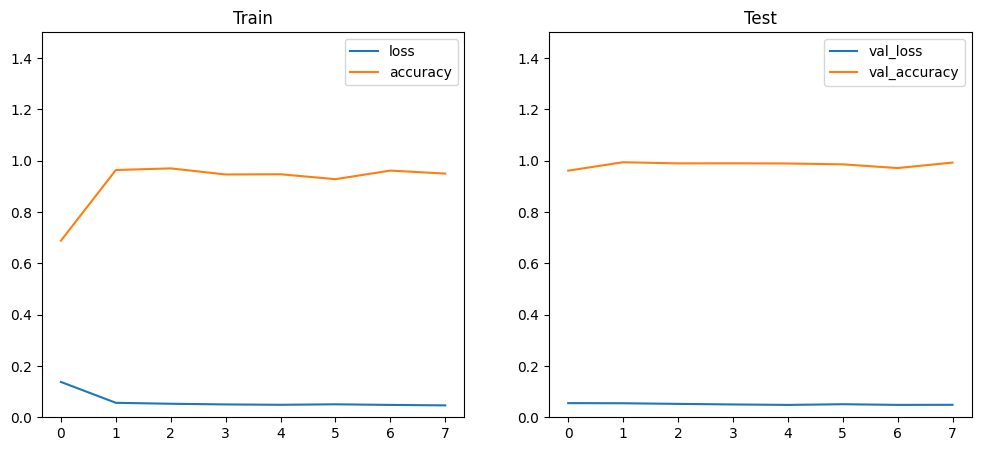

In [ ]:
plot_train(history)

In [ ]:
#save_model(model_transfer_learning)
model_transfer_learning = load_trained_model('best_hater_filter_model.keras')

Modello caricato con successo da best_hater_filter_model.keras!


Valutiamo il modello LSTM-Glove

In [ ]:
evaluate_model_multilabel(model_transfer_learning, X_test_padded, y_test, threshold=THRESHOLD)

#Commento pulito
predict_new_comment(model_transfer_learning, tokenizer, "This technology forum has great discussions and ideas.")

#Commento tossico
predict_new_comment(model_transfer_learning, tokenizer, "You are a stupid idiot and I hate your ugly pig face.")


VALUTAZIONE MODELLO
499/499 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step

--- Metriche di Valutazione (Soglia: 0.4) ---
Accuratezza Globale (Intera riga corretta): 0.9176
Precision Micro (Globale): 0.7567
Recall Micro (Globale): 0.7207
F1-Score Micro (Globale): 0.7383

F1-Score per Categoria:
 - toxic          : 0.7682
 - severe_toxic   : 0.4686
 - obscene        : 0.8033
 - threat         : 0.0000
 - insult         : 0.7208
 - identity_hate  : 0.3820
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

--- Analisi del Commento ---
Commento: 'this technology forum has great discussions and ideas.'
Predizioni (0=Assente, 1=Presente):
 - toxic          : Pulito (0.00)
 - severe_toxic   : Pulito (0.00)
 - obscene        : Pulito (0.00)
 - threat         : Pulito (0.00)
 - insult         : Pulito (0.00)
 - identity_hate  : Pulito (0.00)

RISULTATO: Commento accettabile.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

--- Analisi del Commento ---
Commento: 'you are a stupid idiot and i hate your ugly pig face.'
Predizioni

---